In [3]:
import qeg_nmr_qua as qnmr

from qualang_tools.units import unit
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import jn
import time

u = unit(coerce_to_integer=True)

2026-06-25 14:07:48,162 - qm - INFO     - Starting session: aaf8cb75-8911-4adf-b796-5e2b892440b0


In [ ]:
param_range = np.linspace(-.05, 0.05, 5)
i=0
for u0 in param_range:
    print(f"u = "+str(u0))

    for v in param_range:
        print(f"  v = "+str(v))

        for w in param_range:
            print(f"    w = "+str(w))
            i += 1
            print(i)
    

u = -0.05
  v = -0.05
    w = -0.05
1
    w = -0.025
2
    w = 0.0
3
    w = 0.02500000000000001
4
    w = 0.05
5
  v = -0.025
    w = -0.05
6
    w = -0.025
7
    w = 0.0
8
    w = 0.02500000000000001
9
    w = 0.05
10
  v = 0.0
    w = -0.05
11
    w = -0.025
12
    w = 0.0
13
    w = 0.02500000000000001
14
    w = 0.05
15
  v = 0.02500000000000001
    w = -0.05
16
    w = -0.025
17
    w = 0.0
18
    w = 0.02500000000000001
19
    w = 0.05
20
  v = 0.05
    w = -0.05
21
    w = -0.025
22
    w = 0.0
23
    w = 0.02500000000000001
24
    w = 0.05
25
u = -0.025
  v = -0.05
    w = -0.05
26
    w = -0.025
27
    w = 0.0
28
    w = 0.02500000000000001
29
    w = 0.05
30
  v = -0.025
    w = -0.05
31
    w = -0.025
32
    w = 0.0
33
    w = 0.02500000000000001
34
    w = 0.05
35
  v = 0.0
    w = -0.05
36
    w = -0.025
37
    w = 0.0
38
    w = 0.02500000000000001
39
    w = 0.05
40
  v = 0.02500000000000001
    w = -0.05
41
    w = -0.025
42
    w = 0.0
43
    w = 0.02500000000000001
4

In [ ]:
for δ in (-.025,-.02,-.015,-.01,-.005,0,.005,.01,.015,.02,.025):
    print("Testing δ=" + str(δ) + " now.")

    a=-0.000091; b=0.000389; c=-0.000916; u0=-0.006521; v=0.006974; w=-0.000093
    u0-=δ; v+=δ

    print(u0,v,w)

Testing δ=-0.025 now.
0.018479000000000002 -0.018026 -9.3e-05
Testing δ=-0.02 now.
0.013479000000000001 -0.013026 -9.3e-05
Testing δ=-0.015 now.
0.008479 -0.008025999999999998 -9.3e-05
Testing δ=-0.01 now.
0.0034790000000000003 -0.003026 -9.3e-05
Testing δ=-0.005 now.
-0.0015209999999999998 0.001974 -9.3e-05
Testing δ=0 now.
-0.006521 0.006974 -9.3e-05
Testing δ=0.005 now.
-0.011521 0.011974 -9.3e-05
Testing δ=0.01 now.
-0.016521 0.016974 -9.3e-05
Testing δ=0.015 now.
-0.021521 0.021974 -9.3e-05
Testing δ=0.02 now.
-0.026521 0.026974 -9.3e-05
Testing δ=0.025 now.
-0.031521 0.031974 -9.3e-05


In [7]:
t0 = 5.0 * u.us
a,b,c,u0,v,w = [5.8473e-03, -1.1341e-02, 1.1165e-02, -4.7430e-02, 1.2494e-01, 1.2248e-01]
# a,b,c,u0,v,w = [5.5087e-03, -1.0372e-02, 1.9857e-02, -7.9646e-02, 8.8294e-02, 8.5725e-02]

tp = 1.24*u.us
t1  = t0*(1+c-v+w)  - tp/2
t1p = t0*(1-c-v+w)  - tp/2
t2  = t0*(1+b-u0+v) - tp
t2p = t0*(1-b-u0+v) - tp
t3  = t0*(1-a+u0-w) - tp/2
t3p = t0*(1+a+u0-w) - tp/2

# Sequence pattern for engineering H
alt32_phases = np.array([0,90,90,0,      0,90,90,0,      180,270,270,180,  180,270,270,180,
                         90,180,180,90,  90,180,180,90,  270,0,0,270,      270,0,0,270])
alt32_delays = np.array([t1,  t2,  2*t3,  t2p, t1p +
                         t1p, t2,  2*t3p, t2p, t1  +
                         t1,  t2p, 2*t3p, t2,  t1p +
                         t1p, t2p, 2*t3,  t2,  t1  +
                         t1,  t2,  2*t3,  t2p, t1p +
                         t1p, t2,  2*t3p, t2p, t1  +
                         t1,  t2p, 2*t3p, t2,  t1p +
                         t1p, t2p, 2*t3,  t2,  t1])
print(alt32_delays)

[4423.525 4565.145 7002.427 4678.555 8623.75  4565.145 7119.373 4678.555
 8847.05  4678.555 7119.373 4565.145 8623.75  4678.555 7002.427 4565.145
 8847.05  4565.145 7002.427 4678.555 8623.75  4565.145 7119.373 4678.555
 8847.05  4678.555 7119.373 4565.145 8623.75  4678.555 7002.427 4565.145
 4423.525]


(datetime.datetime(2026, 2, 24, 16, 38, 27, 241341), datetime.datetime(2026, 2, 24, 16, 53, 50, 229264), datetime.datetime(2026, 2, 24, 17, 8, 4, 355733), datetime.datetime(2026, 2, 24, 17, 8, 55, 339691), datetime.datetime(2026, 2, 24, 17, 9, 29, 319998), datetime.datetime(2026, 2, 24, 17, 10, 9, 691215), datetime.datetime(2026, 2, 24, 17, 10, 48, 652248), datetime.datetime(2026, 2, 24, 17, 12, 40, 830262), datetime.datetime(2026, 2, 24, 17, 13, 32, 735308), datetime.datetime(2026, 3, 2, 11, 49, 34, 960058), datetime.datetime(2026, 3, 2, 16, 23, 23, 637851), datetime.datetime(2026, 3, 2, 16, 24, 22, 496485), datetime.datetime(2026, 3, 2, 16, 25, 10, 648402), datetime.datetime(2026, 3, 2, 16, 26, 10, 152196), datetime.datetime(2026, 3, 2, 16, 27, 5, 671113), datetime.datetime(2026, 3, 2, 16, 27, 41, 830110), datetime.datetime(2026, 3, 2, 16, 28, 30, 37735), datetime.datetime(2026, 3, 2, 16, 29, 8, 773676), datetime.datetime(2026, 3, 2, 16, 29, 59, 152677), datetime.datetime(2026, 3, 2,

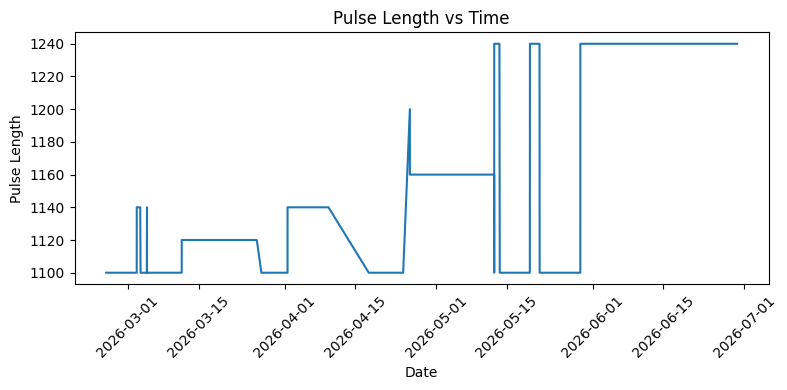

In [30]:
from pathlib import Path
import json
from datetime import datetime
import matplotlib.pyplot as plt

base_dir = Path.home() / "Dropbox/QEG/NMR/RawData" / "zg"

dates = []
pulse_lengths = []

# Date range you want
start_date = datetime(2024, 1, 1)
end_date = datetime(2026, 6, 30)

for exp_dir in sorted(base_dir.glob("experiment_*")):
    settings_path = exp_dir / "settings.json"

    if not settings_path.exists():
        continue

    # Read pulse length
    with open(settings_path, "r") as f:
        settings = json.load(f)

    pulse_length = settings["pulse_length"]

    # Get file timestamp
    stat = settings_path.stat()

    # Windows: creation time
    # Linux/macOS: consider using stat.st_mtime instead
    timestamp = datetime.fromtimestamp(settings_path.stat().st_ctime)

    # Skip experiments outside the desired range
    if not (start_date <= timestamp <= end_date):
        continue
    if not (pulse_length < 1500):
        continue

    dates.append(timestamp)
    pulse_lengths.append(pulse_length)

# Sort by date in case folder names are out of order
dates, pulse_lengths = zip(*sorted(zip(dates, pulse_lengths)))
print(str(dates))
print(pulse_lengths)

plt.figure(figsize=(8, 4))
plt.plot(dates, pulse_lengths)
plt.xlabel("Date")
plt.ylabel("Pulse Length")
plt.title("Pulse Length vs Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
import csv
import datetime

# Paste your two tuples here
dates = (datetime.datetime(2026, 2, 24, 16, 38, 27, 241341), datetime.datetime(2026, 2, 24, 16, 53, 50, 229264), datetime.datetime(2026, 2, 24, 17, 8, 4, 355733), datetime.datetime(2026, 2, 24, 17, 8, 55, 339691), datetime.datetime(2026, 2, 24, 17, 9, 29, 319998), datetime.datetime(2026, 2, 24, 17, 10, 9, 691215), datetime.datetime(2026, 2, 24, 17, 10, 48, 652248), datetime.datetime(2026, 2, 24, 17, 12, 40, 830262), datetime.datetime(2026, 2, 24, 17, 13, 32, 735308), datetime.datetime(2026, 3, 2, 11, 49, 34, 960058), datetime.datetime(2026, 3, 2, 16, 23, 23, 637851), datetime.datetime(2026, 3, 2, 16, 24, 22, 496485), datetime.datetime(2026, 3, 2, 16, 25, 10, 648402), datetime.datetime(2026, 3, 2, 16, 26, 10, 152196), datetime.datetime(2026, 3, 2, 16, 27, 5, 671113), datetime.datetime(2026, 3, 2, 16, 27, 41, 830110), datetime.datetime(2026, 3, 2, 16, 28, 30, 37735), datetime.datetime(2026, 3, 2, 16, 29, 8, 773676), datetime.datetime(2026, 3, 2, 16, 29, 59, 152677), datetime.datetime(2026, 3, 2, 16, 35, 5, 807452), datetime.datetime(2026, 3, 2, 16, 35, 55, 961371), datetime.datetime(2026, 3, 2, 16, 36, 31, 417009), datetime.datetime(2026, 3, 2, 16, 45, 40, 454838), datetime.datetime(2026, 3, 2, 16, 46, 24, 306649), datetime.datetime(2026, 3, 2, 17, 38, 35, 183361), datetime.datetime(2026, 3, 2, 17, 56, 41, 258018), datetime.datetime(2026, 3, 3, 10, 20, 33, 563545), datetime.datetime(2026, 3, 3, 10, 21, 9, 382679), datetime.datetime(2026, 3, 3, 11, 57, 28, 494353), datetime.datetime(2026, 3, 3, 11, 59, 39, 193292), datetime.datetime(2026, 3, 3, 12, 0, 19, 927218), datetime.datetime(2026, 3, 3, 12, 1, 20, 851228), datetime.datetime(2026, 3, 4, 17, 56, 10, 768119), datetime.datetime(2026, 3, 4, 18, 28, 57, 100463), datetime.datetime(2026, 3, 4, 18, 30, 14, 106317), datetime.datetime(2026, 3, 4, 18, 31, 16, 351924), datetime.datetime(2026, 3, 9, 16, 58, 37, 421729), datetime.datetime(2026, 3, 9, 18, 44, 24, 92634), datetime.datetime(2026, 3, 9, 18, 45, 24, 480996), datetime.datetime(2026, 3, 9, 18, 46, 10, 334229), datetime.datetime(2026, 3, 11, 12, 54, 56, 760548), datetime.datetime(2026, 3, 11, 12, 55, 52, 429729), datetime.datetime(2026, 3, 11, 15, 28, 15, 621976), datetime.datetime(2026, 3, 11, 15, 29, 2, 674598), datetime.datetime(2026, 3, 11, 15, 33, 1, 746522), datetime.datetime(2026, 3, 11, 16, 19, 37, 180043), datetime.datetime(2026, 3, 11, 16, 22, 15, 951928), datetime.datetime(2026, 3, 17, 0, 40, 41, 598567), datetime.datetime(2026, 3, 17, 15, 5, 50, 72570), datetime.datetime(2026, 3, 17, 15, 8, 34, 944504), datetime.datetime(2026, 3, 17, 15, 9, 7, 976967), datetime.datetime(2026, 3, 17, 15, 10, 18, 701365), datetime.datetime(2026, 3, 17, 15, 10, 39, 729347), datetime.datetime(2026, 3, 17, 15, 11, 19, 292352), datetime.datetime(2026, 3, 17, 15, 49, 54, 32752), datetime.datetime(2026, 3, 17, 15, 53, 9, 63137), datetime.datetime(2026, 3, 17, 16, 1, 44, 529551), datetime.datetime(2026, 3, 17, 16, 2, 20, 616019), datetime.datetime(2026, 3, 17, 16, 10, 2, 784403), datetime.datetime(2026, 3, 17, 16, 10, 40, 606940), datetime.datetime(2026, 3, 17, 16, 17, 14, 845043), datetime.datetime(2026, 3, 17, 16, 17, 54, 658197), datetime.datetime(2026, 3, 17, 16, 18, 34, 875558), datetime.datetime(2026, 3, 17, 16, 19, 52, 98543), datetime.datetime(2026, 3, 17, 16, 21, 35, 438720), datetime.datetime(2026, 3, 17, 16, 21, 59, 127255), datetime.datetime(2026, 3, 17, 16, 22, 53, 852169), datetime.datetime(2026, 3, 17, 16, 23, 39, 673404), datetime.datetime(2026, 3, 17, 16, 24, 37, 512195), datetime.datetime(2026, 3, 17, 16, 25, 28, 781017), datetime.datetime(2026, 3, 17, 16, 26, 45, 525602), datetime.datetime(2026, 3, 17, 16, 27, 47, 41741), datetime.datetime(2026, 3, 17, 16, 28, 34, 484937), datetime.datetime(2026, 3, 17, 16, 29, 26, 578788), datetime.datetime(2026, 3, 17, 16, 30, 16, 330913), datetime.datetime(2026, 3, 17, 16, 30, 59, 303615), datetime.datetime(2026, 3, 17, 16, 32, 40, 350262), datetime.datetime(2026, 3, 17, 16, 33, 21, 990668), datetime.datetime(2026, 3, 17, 16, 34, 2, 838313), datetime.datetime(2026, 3, 17, 16, 34, 45, 865496), datetime.datetime(2026, 3, 17, 16, 35, 29, 800786), datetime.datetime(2026, 3, 17, 16, 36, 14, 169207), datetime.datetime(2026, 3, 17, 16, 36, 57, 303514), datetime.datetime(2026, 3, 17, 16, 37, 36, 652806), datetime.datetime(2026, 3, 17, 16, 38, 11, 426070), datetime.datetime(2026, 3, 17, 16, 38, 47, 471759), datetime.datetime(2026, 3, 17, 16, 39, 28, 526134), datetime.datetime(2026, 3, 18, 14, 13, 18, 715278), datetime.datetime(2026, 3, 18, 14, 14, 14, 442740), datetime.datetime(2026, 3, 18, 14, 15, 0, 61148), datetime.datetime(2026, 3, 19, 15, 52, 5, 243244), datetime.datetime(2026, 3, 19, 17, 56, 21, 860965), datetime.datetime(2026, 3, 19, 18, 2, 31, 246439), datetime.datetime(2026, 3, 19, 18, 44, 8, 800383), datetime.datetime(2026, 3, 22, 20, 59, 5, 680988), datetime.datetime(2026, 3, 22, 20, 59, 58, 682553), datetime.datetime(2026, 3, 22, 21, 2, 41, 905031), datetime.datetime(2026, 3, 22, 21, 35, 49, 8004), datetime.datetime(2026, 3, 22, 21, 36, 23, 187121), datetime.datetime(2026, 3, 22, 21, 37, 3, 161061), datetime.datetime(2026, 3, 22, 21, 38, 6, 954541), datetime.datetime(2026, 3, 22, 21, 42, 50, 205565), datetime.datetime(2026, 3, 22, 21, 47, 31, 311466), datetime.datetime(2026, 3, 22, 21, 48, 10, 74350), datetime.datetime(2026, 3, 22, 21, 48, 57, 743957), datetime.datetime(2026, 3, 22, 21, 49, 20, 683315), datetime.datetime(2026, 3, 22, 21, 49, 59, 98630), datetime.datetime(2026, 3, 22, 21, 50, 46, 229944), datetime.datetime(2026, 3, 22, 21, 51, 26, 476889), datetime.datetime(2026, 3, 22, 21, 52, 8, 700212), datetime.datetime(2026, 3, 22, 21, 53, 5, 728632), datetime.datetime(2026, 3, 22, 22, 9, 17, 72668), datetime.datetime(2026, 3, 22, 22, 15, 26, 568274), datetime.datetime(2026, 3, 22, 22, 16, 6, 666833), datetime.datetime(2026, 3, 22, 22, 17, 34, 127550), datetime.datetime(2026, 3, 23, 0, 42, 16, 837569), datetime.datetime(2026, 3, 26, 12, 17, 14, 791715), datetime.datetime(2026, 3, 26, 12, 17, 53, 687887), datetime.datetime(2026, 3, 26, 12, 18, 46, 329909), datetime.datetime(2026, 3, 26, 12, 19, 33, 951594), datetime.datetime(2026, 3, 26, 12, 20, 29, 874266), datetime.datetime(2026, 3, 26, 12, 21, 10, 330161), datetime.datetime(2026, 3, 27, 10, 0, 40, 609633), datetime.datetime(2026, 3, 27, 10, 1, 28, 629915), datetime.datetime(2026, 3, 27, 10, 2, 12, 783845), datetime.datetime(2026, 3, 30, 11, 43, 29, 866058), datetime.datetime(2026, 3, 30, 16, 13, 31, 786472), datetime.datetime(2026, 3, 30, 16, 14, 17, 88692), datetime.datetime(2026, 3, 30, 16, 15, 3, 319816), datetime.datetime(2026, 3, 30, 16, 16, 14, 330955), datetime.datetime(2026, 3, 30, 16, 16, 54, 636887), datetime.datetime(2026, 3, 30, 16, 17, 34, 746083), datetime.datetime(2026, 3, 30, 16, 18, 16, 332667), datetime.datetime(2026, 3, 30, 16, 18, 55, 66774), datetime.datetime(2026, 3, 30, 16, 19, 31, 343994), datetime.datetime(2026, 3, 30, 16, 20, 5, 615067), datetime.datetime(2026, 3, 30, 16, 20, 41, 860665), datetime.datetime(2026, 3, 30, 17, 50, 1, 487808), datetime.datetime(2026, 3, 31, 13, 34, 14, 89177), datetime.datetime(2026, 3, 31, 13, 34, 50, 263799), datetime.datetime(2026, 3, 31, 13, 35, 31, 552972), datetime.datetime(2026, 4, 1, 14, 11, 17, 487515), datetime.datetime(2026, 4, 1, 14, 11, 53, 789326), datetime.datetime(2026, 4, 1, 14, 12, 29, 813892), datetime.datetime(2026, 4, 1, 14, 13, 8, 523034), datetime.datetime(2026, 4, 1, 14, 13, 47, 84338), datetime.datetime(2026, 4, 1, 14, 14, 30, 601513), datetime.datetime(2026, 4, 1, 14, 14, 58, 585001), datetime.datetime(2026, 4, 1, 14, 15, 39, 419827), datetime.datetime(2026, 4, 1, 14, 16, 16, 79509), datetime.datetime(2026, 4, 1, 14, 21, 22, 650869), datetime.datetime(2026, 4, 1, 14, 22, 45, 184120), datetime.datetime(2026, 4, 1, 14, 23, 27, 319909), datetime.datetime(2026, 4, 1, 14, 24, 4, 225906), datetime.datetime(2026, 4, 1, 14, 24, 39, 786603), datetime.datetime(2026, 4, 1, 17, 53, 39, 235729), datetime.datetime(2026, 4, 1, 17, 54, 18, 664136), datetime.datetime(2026, 4, 1, 17, 55, 59, 39012), datetime.datetime(2026, 4, 1, 17, 56, 35, 327078), datetime.datetime(2026, 4, 6, 16, 16, 50, 712044), datetime.datetime(2026, 4, 9, 16, 44, 18, 813367), datetime.datetime(2026, 4, 9, 16, 44, 43, 601685), datetime.datetime(2026, 4, 9, 16, 45, 21, 923874), datetime.datetime(2026, 4, 9, 16, 45, 43, 453484), datetime.datetime(2026, 4, 9, 16, 46, 23, 929263), datetime.datetime(2026, 4, 9, 16, 47, 4, 570088), datetime.datetime(2026, 4, 17, 16, 8, 22, 92301), datetime.datetime(2026, 4, 17, 16, 9, 13, 517710), datetime.datetime(2026, 4, 17, 16, 9, 41, 87879), datetime.datetime(2026, 4, 17, 16, 10, 25, 124399), datetime.datetime(2026, 4, 17, 16, 11, 4, 777403), datetime.datetime(2026, 4, 17, 16, 11, 49, 336248), datetime.datetime(2026, 4, 17, 16, 12, 27, 933097), datetime.datetime(2026, 4, 17, 16, 13, 20, 307333), datetime.datetime(2026, 4, 17, 16, 14, 38, 35237), datetime.datetime(2026, 4, 24, 11, 39, 57, 737518), datetime.datetime(2026, 4, 24, 11, 41, 8, 472841), datetime.datetime(2026, 4, 24, 11, 41, 47, 156138), datetime.datetime(2026, 4, 24, 11, 42, 24, 674692), datetime.datetime(2026, 4, 24, 11, 43, 3, 530239), datetime.datetime(2026, 4, 24, 11, 43, 46, 51045), datetime.datetime(2026, 4, 24, 11, 44, 46, 506909), datetime.datetime(2026, 4, 25, 19, 39, 1, 561930), datetime.datetime(2026, 4, 25, 19, 39, 33, 110049), datetime.datetime(2026, 4, 27, 13, 17, 23, 780120), datetime.datetime(2026, 4, 27, 13, 19, 6, 674748), datetime.datetime(2026, 4, 27, 13, 19, 53, 122190), datetime.datetime(2026, 4, 27, 13, 20, 40, 633068), datetime.datetime(2026, 4, 27, 13, 21, 18, 162272), datetime.datetime(2026, 4, 27, 13, 21, 53, 485378), datetime.datetime(2026, 4, 27, 13, 22, 31, 376242), datetime.datetime(2026, 4, 27, 20, 10, 28, 90180), datetime.datetime(2026, 5, 7, 16, 5, 37, 74125), datetime.datetime(2026, 5, 7, 16, 6, 6, 288468), datetime.datetime(2026, 5, 7, 16, 6, 39, 183472), datetime.datetime(2026, 5, 7, 16, 7, 53, 689473), datetime.datetime(2026, 5, 7, 16, 8, 31, 569914), datetime.datetime(2026, 5, 12, 12, 3, 57, 241508), datetime.datetime(2026, 5, 12, 12, 5, 43, 442258), datetime.datetime(2026, 5, 12, 12, 6, 29, 52546), datetime.datetime(2026, 5, 12, 12, 10, 34, 804569), datetime.datetime(2026, 5, 12, 12, 11, 22, 684527), datetime.datetime(2026, 5, 12, 12, 12, 8, 76857), datetime.datetime(2026, 5, 12, 12, 12, 58, 79022), datetime.datetime(2026, 5, 12, 12, 15, 29, 615119), datetime.datetime(2026, 5, 12, 12, 16, 11, 646642), datetime.datetime(2026, 5, 12, 12, 16, 54, 906010), datetime.datetime(2026, 5, 12, 12, 17, 53, 783110), datetime.datetime(2026, 5, 12, 12, 25, 47, 223525), datetime.datetime(2026, 5, 12, 12, 30, 26, 885397), datetime.datetime(2026, 5, 12, 12, 31, 25, 397460), datetime.datetime(2026, 5, 12, 12, 37, 30, 416601), datetime.datetime(2026, 5, 12, 12, 39, 35, 491051), datetime.datetime(2026, 5, 12, 12, 41, 11, 479377), datetime.datetime(2026, 5, 12, 12, 41, 59, 299844), datetime.datetime(2026, 5, 12, 13, 14, 42, 49429), datetime.datetime(2026, 5, 12, 13, 15, 26, 671259), datetime.datetime(2026, 5, 13, 13, 3, 35, 808148), datetime.datetime(2026, 5, 13, 13, 4, 27, 158631), datetime.datetime(2026, 5, 13, 13, 6, 12, 919269), datetime.datetime(2026, 5, 13, 13, 6, 43, 373807), datetime.datetime(2026, 5, 13, 13, 8, 43, 855815), datetime.datetime(2026, 5, 13, 13, 10, 17, 88979), datetime.datetime(2026, 5, 13, 13, 12, 2, 170425), datetime.datetime(2026, 5, 13, 13, 12, 35, 655600), datetime.datetime(2026, 5, 13, 14, 40, 28, 147734), datetime.datetime(2026, 5, 13, 14, 42, 50, 714487), datetime.datetime(2026, 5, 13, 15, 48, 14, 944676), datetime.datetime(2026, 5, 13, 15, 49, 20, 457689), datetime.datetime(2026, 5, 13, 15, 49, 52, 578210), datetime.datetime(2026, 5, 13, 15, 50, 36, 810480), datetime.datetime(2026, 5, 13, 15, 51, 39, 826838), datetime.datetime(2026, 5, 13, 15, 52, 24, 849862), datetime.datetime(2026, 5, 13, 15, 53, 12, 787390), datetime.datetime(2026, 5, 13, 15, 53, 37, 427939), datetime.datetime(2026, 5, 13, 15, 54, 0, 129652), datetime.datetime(2026, 5, 13, 15, 54, 27, 907000), datetime.datetime(2026, 5, 13, 15, 55, 17, 589180), datetime.datetime(2026, 5, 13, 15, 55, 45, 947082), datetime.datetime(2026, 5, 13, 15, 56, 15, 66632), datetime.datetime(2026, 5, 13, 16, 14, 26, 863111), datetime.datetime(2026, 5, 13, 16, 14, 52, 747857), datetime.datetime(2026, 5, 13, 16, 15, 16, 369602), datetime.datetime(2026, 5, 13, 16, 15, 47, 444780), datetime.datetime(2026, 5, 13, 16, 16, 8, 872334), datetime.datetime(2026, 5, 13, 16, 16, 34, 482190), datetime.datetime(2026, 5, 13, 16, 17, 1, 97946), datetime.datetime(2026, 5, 13, 16, 17, 24, 332587), datetime.datetime(2026, 5, 13, 16, 17, 42, 710822), datetime.datetime(2026, 5, 13, 16, 24, 17, 400170), datetime.datetime(2026, 5, 19, 13, 33, 3, 891330), datetime.datetime(2026, 5, 19, 13, 34, 18, 445570), datetime.datetime(2026, 5, 19, 13, 35, 10, 130614), datetime.datetime(2026, 5, 19, 14, 5, 21, 58034), datetime.datetime(2026, 5, 19, 14, 6, 15, 570122), datetime.datetime(2026, 5, 19, 14, 6, 58, 441651), datetime.datetime(2026, 5, 19, 14, 7, 52, 18930), datetime.datetime(2026, 5, 19, 14, 8, 51, 524232), datetime.datetime(2026, 5, 19, 14, 9, 56, 565064), datetime.datetime(2026, 5, 19, 14, 39, 20, 399207), datetime.datetime(2026, 5, 19, 14, 42, 46, 633994), datetime.datetime(2026, 5, 19, 14, 43, 33, 515980), datetime.datetime(2026, 5, 20, 14, 43, 11, 933053), datetime.datetime(2026, 5, 20, 14, 43, 33, 930387), datetime.datetime(2026, 5, 20, 14, 44, 0, 622931), datetime.datetime(2026, 5, 21, 11, 17, 2, 960293), datetime.datetime(2026, 5, 21, 11, 17, 48, 490378), datetime.datetime(2026, 5, 21, 11, 40, 41, 545331), datetime.datetime(2026, 5, 21, 11, 41, 10, 214610), datetime.datetime(2026, 5, 21, 11, 41, 38, 494869), datetime.datetime(2026, 5, 21, 11, 42, 42, 160458), datetime.datetime(2026, 5, 21, 11, 43, 11, 8149), datetime.datetime(2026, 5, 21, 11, 43, 57, 607254), datetime.datetime(2026, 5, 21, 11, 44, 45, 979586), datetime.datetime(2026, 5, 21, 11, 45, 36, 220762), datetime.datetime(2026, 5, 21, 11, 46, 21, 879533), datetime.datetime(2026, 5, 21, 11, 47, 10, 723851), datetime.datetime(2026, 5, 21, 11, 47, 58, 97828), datetime.datetime(2026, 5, 21, 11, 48, 41, 957044), datetime.datetime(2026, 5, 21, 11, 51, 56, 459804), datetime.datetime(2026, 5, 21, 11, 56, 16, 776084), datetime.datetime(2026, 5, 21, 12, 13, 42, 772184), datetime.datetime(2026, 5, 21, 12, 15, 1, 239513), datetime.datetime(2026, 5, 21, 12, 15, 53, 9415), datetime.datetime(2026, 5, 21, 12, 30, 59, 392458), datetime.datetime(2026, 5, 21, 12, 31, 40, 253990), datetime.datetime(2026, 5, 21, 14, 17, 42, 842395), datetime.datetime(2026, 5, 21, 14, 18, 20, 329239), datetime.datetime(2026, 5, 21, 14, 19, 37, 690601), datetime.datetime(2026, 5, 21, 14, 20, 21, 249563), datetime.datetime(2026, 5, 21, 14, 20, 45, 602029), datetime.datetime(2026, 5, 21, 14, 21, 20, 21345), datetime.datetime(2026, 5, 21, 14, 22, 23, 240730), datetime.datetime(2026, 5, 21, 14, 24, 8, 205904), datetime.datetime(2026, 5, 21, 14, 24, 29, 443637), datetime.datetime(2026, 5, 21, 14, 26, 19, 429791), datetime.datetime(2026, 5, 21, 14, 29, 7, 53606), datetime.datetime(2026, 5, 21, 14, 29, 24, 438673), datetime.datetime(2026, 5, 21, 14, 29, 57, 741569), datetime.datetime(2026, 5, 21, 14, 30, 44, 354574), datetime.datetime(2026, 5, 21, 14, 34, 3, 964439), datetime.datetime(2026, 5, 28, 18, 8, 46, 851188), datetime.datetime(2026, 5, 28, 18, 9, 32, 79040), datetime.datetime(2026, 5, 28, 18, 10, 21, 775115), datetime.datetime(2026, 5, 28, 18, 11, 5, 675177), datetime.datetime(2026, 5, 28, 18, 12, 0, 277885), datetime.datetime(2026, 5, 29, 13, 28, 30, 275850), datetime.datetime(2026, 5, 29, 13, 30, 22, 211216), datetime.datetime(2026, 5, 29, 13, 31, 19, 951288), datetime.datetime(2026, 5, 29, 13, 41, 11, 363003), datetime.datetime(2026, 5, 29, 13, 42, 3, 856788), datetime.datetime(2026, 6, 2, 17, 35, 2, 846007), datetime.datetime(2026, 6, 2, 17, 35, 37, 132296), datetime.datetime(2026, 6, 2, 17, 36, 12, 999), datetime.datetime(2026, 6, 2, 17, 36, 56, 357414), datetime.datetime(2026, 6, 2, 17, 37, 36, 678456), datetime.datetime(2026, 6, 2, 17, 38, 14, 774283), datetime.datetime(2026, 6, 2, 17, 40, 5, 63726), datetime.datetime(2026, 6, 2, 17, 41, 4, 555897), datetime.datetime(2026, 6, 2, 17, 42, 53, 450738), datetime.datetime(2026, 6, 2, 17, 44, 10, 536301), datetime.datetime(2026, 6, 3, 17, 13, 22, 506987), datetime.datetime(2026, 6, 3, 17, 13, 59, 885083), datetime.datetime(2026, 6, 3, 17, 15, 0, 664416), datetime.datetime(2026, 6, 3, 17, 17, 42, 529822), datetime.datetime(2026, 6, 3, 17, 18, 17, 929709), datetime.datetime(2026, 6, 3, 17, 19, 8, 441455), datetime.datetime(2026, 6, 3, 17, 19, 50, 46093), datetime.datetime(2026, 6, 3, 17, 20, 24, 959723), datetime.datetime(2026, 6, 4, 12, 8, 46, 710180), datetime.datetime(2026, 6, 4, 12, 9, 27, 769577), datetime.datetime(2026, 6, 4, 12, 11, 5, 178860), datetime.datetime(2026, 6, 4, 12, 11, 55, 525057), datetime.datetime(2026, 6, 4, 13, 30, 3, 370904), datetime.datetime(2026, 6, 5, 9, 10, 6, 135365), datetime.datetime(2026, 6, 5, 9, 10, 47, 780033), datetime.datetime(2026, 6, 5, 9, 46, 38, 440917), datetime.datetime(2026, 6, 8, 15, 2, 39, 586199), datetime.datetime(2026, 6, 8, 15, 4, 3, 263532), datetime.datetime(2026, 6, 8, 15, 4, 50, 114843), datetime.datetime(2026, 6, 8, 15, 11, 21, 158189), datetime.datetime(2026, 6, 8, 15, 12, 13, 799927), datetime.datetime(2026, 6, 10, 16, 58, 30, 532913), datetime.datetime(2026, 6, 10, 16, 59, 15, 260283), datetime.datetime(2026, 6, 10, 16, 59, 55, 310826), datetime.datetime(2026, 6, 10, 17, 0, 38, 115290), datetime.datetime(2026, 6, 10, 17, 1, 26, 75702), datetime.datetime(2026, 6, 10, 17, 2, 4, 536624), datetime.datetime(2026, 6, 10, 17, 3, 23, 948454), datetime.datetime(2026, 6, 10, 17, 4, 13, 102359), datetime.datetime(2026, 6, 10, 17, 35, 58, 717577), datetime.datetime(2026, 6, 16, 12, 55, 6, 854973), datetime.datetime(2026, 6, 16, 12, 55, 46, 752069), datetime.datetime(2026, 6, 16, 12, 56, 42, 566543), datetime.datetime(2026, 6, 17, 9, 45, 15, 200442), datetime.datetime(2026, 6, 17, 9, 45, 48, 235101), datetime.datetime(2026, 6, 17, 9, 46, 34, 846663), datetime.datetime(2026, 6, 17, 9, 47, 18, 582302), datetime.datetime(2026, 6, 17, 9, 47, 56, 587143), datetime.datetime(2026, 6, 17, 9, 49, 45, 593507), datetime.datetime(2026, 6, 17, 9, 59, 4, 960228), datetime.datetime(2026, 6, 17, 9, 59, 44, 576087), datetime.datetime(2026, 6, 17, 10, 1, 0, 791880), datetime.datetime(2026, 6, 17, 12, 18, 44, 555605), datetime.datetime(2026, 6, 18, 16, 32, 59, 805948), datetime.datetime(2026, 6, 18, 16, 33, 52, 242840), datetime.datetime(2026, 6, 18, 16, 34, 31, 460290), datetime.datetime(2026, 6, 18, 16, 35, 10, 540160), datetime.datetime(2026, 6, 18, 16, 35, 43, 959538), datetime.datetime(2026, 6, 18, 16, 36, 30, 119928), datetime.datetime(2026, 6, 18, 16, 58, 2, 968629), datetime.datetime(2026, 6, 18, 16, 58, 49, 146038), datetime.datetime(2026, 6, 18, 17, 4, 22, 488121), datetime.datetime(2026, 6, 18, 17, 5, 11, 239987), datetime.datetime(2026, 6, 18, 17, 5, 55, 507845), datetime.datetime(2026, 6, 18, 17, 6, 31, 956518), datetime.datetime(2026, 6, 18, 17, 7, 4, 734231), datetime.datetime(2026, 6, 18, 17, 7, 38, 584937), datetime.datetime(2026, 6, 18, 17, 8, 2, 603305), datetime.datetime(2026, 6, 18, 17, 8, 41, 906080), datetime.datetime(2026, 6, 18, 17, 9, 30, 708604), datetime.datetime(2026, 6, 18, 17, 10, 0, 462212), datetime.datetime(2026, 6, 18, 17, 10, 25, 592191), datetime.datetime(2026, 6, 18, 17, 11, 0, 705627), datetime.datetime(2026, 6, 18, 17, 11, 34, 406547), datetime.datetime(2026, 6, 18, 17, 12, 7, 437649), datetime.datetime(2026, 6, 18, 17, 12, 30, 903080), datetime.datetime(2026, 6, 18, 17, 12, 53, 215550), datetime.datetime(2026, 6, 18, 17, 13, 19, 25668), datetime.datetime(2026, 6, 18, 17, 23, 45, 261122), datetime.datetime(2026, 6, 18, 17, 38, 47, 303624), datetime.datetime(2026, 6, 18, 17, 39, 55, 466764), datetime.datetime(2026, 6, 18, 17, 40, 21, 100527), datetime.datetime(2026, 6, 18, 17, 40, 40, 698431), datetime.datetime(2026, 6, 18, 17, 40, 57, 331225), datetime.datetime(2026, 6, 18, 17, 41, 24, 198006), datetime.datetime(2026, 6, 18, 17, 42, 39, 7473), datetime.datetime(2026, 6, 18, 17, 57, 29, 250958), datetime.datetime(2026, 6, 18, 17, 58, 0, 692662), datetime.datetime(2026, 6, 22, 18, 11, 16, 594619), datetime.datetime(2026, 6, 22, 18, 11, 59, 99169), datetime.datetime(2026, 6, 22, 18, 13, 9, 825584), datetime.datetime(2026, 6, 22, 18, 15, 6, 751268), datetime.datetime(2026, 6, 22, 18, 15, 45, 985912), datetime.datetime(2026, 6, 22, 18, 16, 29, 613358), datetime.datetime(2026, 6, 22, 18, 17, 4, 246546), datetime.datetime(2026, 6, 22, 18, 18, 5, 844799), datetime.datetime(2026, 6, 22, 18, 24, 41, 829184), datetime.datetime(2026, 6, 22, 18, 25, 23, 56310), datetime.datetime(2026, 6, 22, 18, 26, 2, 481051), datetime.datetime(2026, 6, 22, 18, 26, 42, 882269), datetime.datetime(2026, 6, 23, 0, 3, 31, 47318), datetime.datetime(2026, 6, 23, 0, 4, 25, 649117), datetime.datetime(2026, 6, 23, 0, 6, 1, 689570), datetime.datetime(2026, 6, 23, 0, 6, 45, 356084), datetime.datetime(2026, 6, 23, 0, 7, 37, 284851), datetime.datetime(2026, 6, 23, 0, 8, 14, 226438), datetime.datetime(2026, 6, 23, 0, 31, 52, 430556), datetime.datetime(2026, 6, 23, 0, 32, 38, 360932), datetime.datetime(2026, 6, 23, 9, 9, 22, 288112), datetime.datetime(2026, 6, 23, 9, 10, 0, 329319), datetime.datetime(2026, 6, 23, 9, 10, 56, 190238), datetime.datetime(2026, 6, 23, 9, 11, 46, 108074), datetime.datetime(2026, 6, 23, 9, 13, 41, 932528), datetime.datetime(2026, 6, 23, 9, 14, 17, 754684), datetime.datetime(2026, 6, 23, 9, 15, 0, 594787), datetime.datetime(2026, 6, 24, 16, 19, 34, 431498), datetime.datetime(2026, 6, 24, 16, 20, 18, 125122), datetime.datetime(2026, 6, 24, 16, 21, 45, 721412), datetime.datetime(2026, 6, 24, 17, 23, 31, 291202), datetime.datetime(2026, 6, 25, 11, 57, 9, 31667), datetime.datetime(2026, 6, 25, 11, 57, 42, 353449), datetime.datetime(2026, 6, 25, 12, 6, 57, 647166), datetime.datetime(2026, 6, 25, 12, 7, 32, 355029), datetime.datetime(2026, 6, 25, 12, 9, 14, 204832), datetime.datetime(2026, 6, 25, 12, 12, 36, 594923), datetime.datetime(2026, 6, 25, 12, 14, 27, 847770), datetime.datetime(2026, 6, 25, 12, 14, 59, 78239), datetime.datetime(2026, 6, 25, 12, 15, 41, 153676), datetime.datetime(2026, 6, 25, 12, 23, 28, 663624), datetime.datetime(2026, 6, 25, 12, 24, 16, 501249), datetime.datetime(2026, 6, 26, 12, 14, 6, 765996), datetime.datetime(2026, 6, 26, 12, 19, 14, 305614), datetime.datetime(2026, 6, 26, 12, 21, 40, 203644), datetime.datetime(2026, 6, 26, 12, 28, 55, 157864), datetime.datetime(2026, 6, 26, 12, 29, 34, 997230), datetime.datetime(2026, 6, 26, 12, 30, 16, 4080), datetime.datetime(2026, 6, 26, 12, 30, 59, 645486), datetime.datetime(2026, 6, 26, 12, 31, 45, 904393), datetime.datetime(2026, 6, 26, 12, 36, 36, 316357), datetime.datetime(2026, 6, 26, 12, 37, 31, 239584), datetime.datetime(2026, 6, 26, 12, 38, 5, 500406), datetime.datetime(2026, 6, 26, 12, 43, 32, 246831), datetime.datetime(2026, 6, 26, 12, 44, 13, 304624), datetime.datetime(2026, 6, 29, 14, 18, 10, 554107), datetime.datetime(2026, 6, 29, 14, 38, 13, 908352), datetime.datetime(2026, 6, 29, 14, 38, 53, 705722), datetime.datetime(2026, 6, 29, 14, 39, 44, 130809), datetime.datetime(2026, 6, 29, 14, 40, 26, 676295), datetime.datetime(2026, 6, 29, 14, 41, 5, 649601), datetime.datetime(2026, 6, 29, 14, 42, 7, 514237))

values = (1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1140, 1140, 1140, 1100, 1100, 1100, 1100, 1100, 1140, 1140, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1120, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1140, 1140, 1140, 1140, 1140, 1140, 1140, 1140, 1140, 1140, 1140, 1140, 1140, 1140, 1140, 1140, 1140, 1140, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1200, 1160, 1160, 1160, 1160, 1160, 1160, 1160, 1160, 1160, 1160, 1160, 1160, 1160, 1160, 1160, 1160, 1160, 1160, 1160, 1160, 1160, 1100, 1100, 1100, 1100, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1100, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240, 1240)


with open("output.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Date", "Value"])

    for d, v in zip(dates, values):
        writer.writerow([d.isoformat(), v])

print("CSV written to output.csv")

CSV written to output.csv
